<a href="https://colab.research.google.com/github/Krumca97/ZSU/blob/main/fml_hands_on_clustering_credit_cards.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-on clustering exercise on Credit Card Data

## The goal of this excercise is to complete the hands-on experience task with similar task description as the project has.

**Dataset**

Dataset downloaded for download is here https://www.kaggle.com/arjunbhasin2013/ccdata

And also here: https://raw.githubusercontent.com/jplatos/Fundamentals-of-Machine-Learning/refs/heads/main/CCGENERAL.csv

**Context**

This case requires to develop a customer segmentation to define marketing strategy. The sample Dataset summarizes the usage behavior of about 9000 active credit card holders during the last 6 months. The file is at a customer level with 18 behavioral variables.

**Content**

* CUSTID : Identification of Credit Card holder (Categorical)
* BALANCE : Balance amount left in their account to make purchases
* BALANCEFREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
* PURCHASES : Amount of purchases made from account
* ONEOFFPURCHASES : Maximum purchase amount done in one-go
* INSTALLMENTSPURCHASES : Amount of purchase done in installment
* CASHADVANCE : Cash in advance given by the user
* PURCHASESFREQUENCY : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
* ONEOFFPURCHASESFREQUENCY : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)
* PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)
* CASHADVANCEFREQUENCY : How frequently the cash in advance being paid
* CASHADVANCETRX : Number of Transactions made with "Cash in Advanced"
* PURCHASESTRX : Numbe of purchase transactions made
* CREDITLIMIT : Limit of Credit Card for user
* PAYMENTS : Amount of Payment done by user
* MINIMUM_PAYMENTS : Minimum amount of payments made by user
* PRCFULLPAYMENT : Percent of full payment paid by user
* TENURE : Tenure of credit card service for user


# Goal of the exercises


1. Load the data from as shown in the link bellow.
2. Made the explorative analysis on the data.
3. Evaluate the missing values, scale of the data.
4. Apply k-means or aglomerative clustering and chose the propriate number of clusters.
5. Describe the clusters and their difference.





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance_matrix
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering, DBSCAN

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/jplatos/Fundamentals-of-Machine-Learning/refs/heads/main/CCGENERAL.csv")
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


# Pocet radku a sloupcu



In [ ]:
#pocet radku a sloupcu
df.shape

(8950, 18)

# Datove typy

In [ ]:
#zjisteni datovych typu
df.dtypes

,0
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


# Datove typy

In [ ]:
#zjisteni prazdnych hodnot a jestli vubec
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


# Statistiky
**Balance**

In [ ]:
#prumer
df["BALANCE"].mean()

np.float64(1564.4748276781006)

In [ ]:
#median
df["BALANCE"].median()

873.385231

In [ ]:
#max
df["BALANCE"].max()

19043.13856

In [ ]:
#min
df["BALANCE"].min()

0.0

**Credit Limit**

In [ ]:
#Prumer
df["CREDIT_LIMIT"].mean()

np.float64(4494.449450364621)

In [ ]:
#median
df["CREDIT_LIMIT"].median()

3000.0

**Purchases frequency**

In [ ]:
#Pumer
df["PURCHASES_FREQUENCY"].mean()

np.float64(0.49035054837988823)

# Distribuce dat

**Balance**

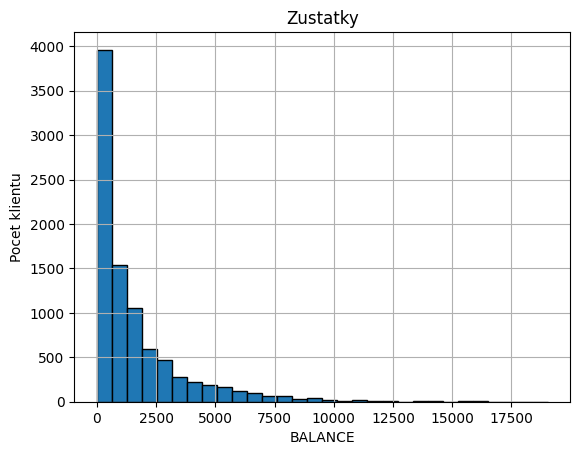

In [ ]:
df["BALANCE"].hist(bins=30, edgecolor="black")
plt.title("Zustatky")
plt.xlabel("BALANCE")
plt.ylabel("Pocet klientu")
plt.show()

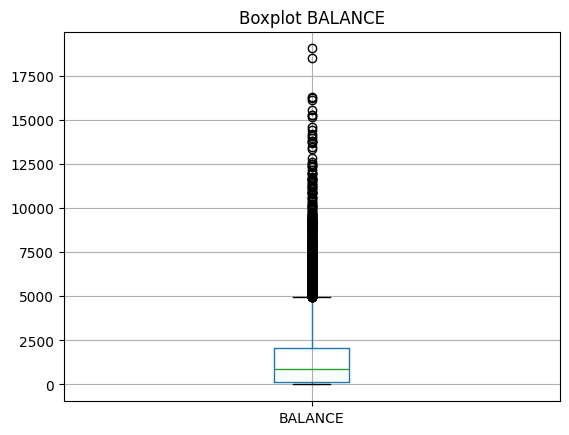

In [ ]:
df.boxplot(column="BALANCE")
plt.title("Boxplot BALANCE")
plt.show()


**Nakupy**

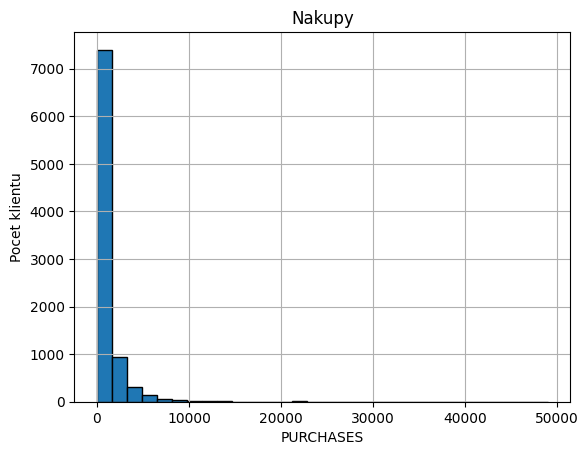

In [ ]:
df["PURCHASES"].hist(bins=30, edgecolor="black")
plt.title("Nakupy")
plt.xlabel("PURCHASES")
plt.ylabel("Pocet klientu")
plt.show()


**Minimalni platby**

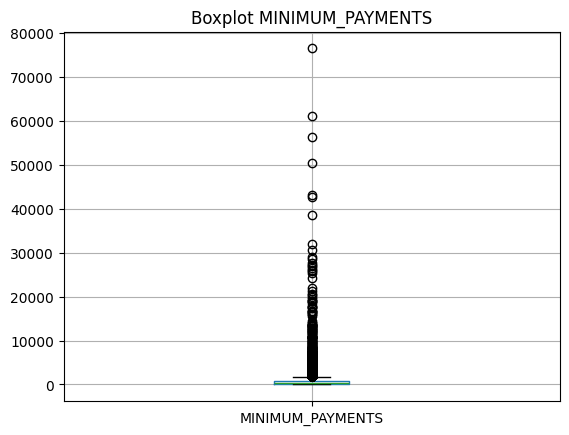

In [ ]:
df.boxplot(column="MINIMUM_PAYMENTS")
plt.title("Boxplot MINIMUM_PAYMENTS")
plt.show()


**Balance vs Payments**

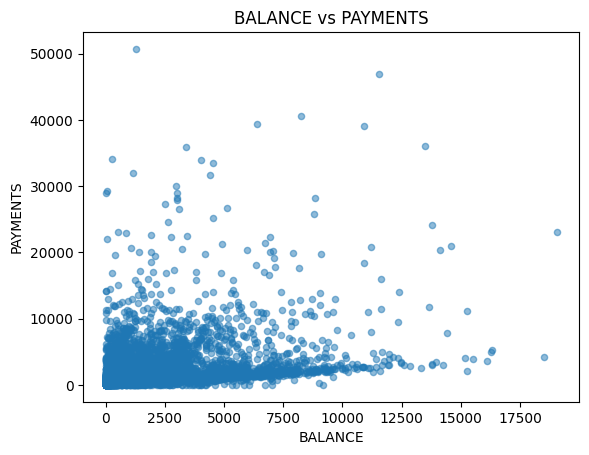

In [ ]:
df.plot.scatter(x="BALANCE", y="PAYMENTS", alpha=0.5)
plt.title("BALANCE vs PAYMENTS")
plt.show()


**Kredit limit**

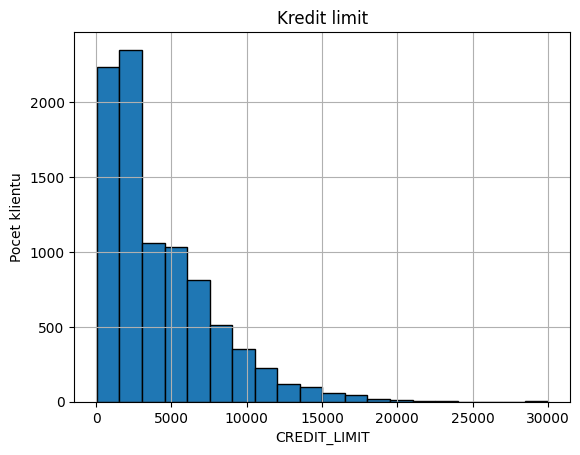

In [ ]:
df["CREDIT_LIMIT"].hist(bins=20, edgecolor="black")
plt.title("Kredit limit")
plt.xlabel("CREDIT_LIMIT")
plt.ylabel("Pocet klientu")
plt.show()


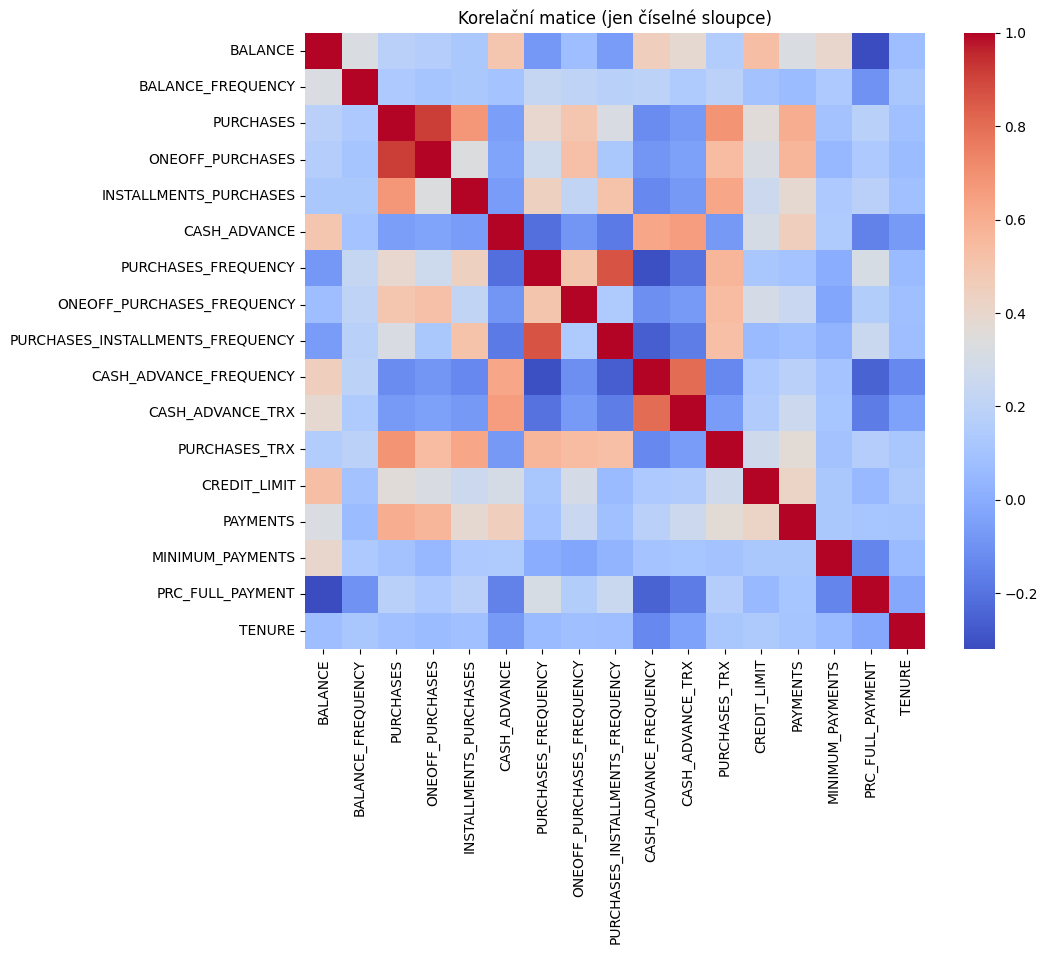

In [ ]:
# Vyber pouze číselné sloupce
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Korelacni matice")
plt.show()


# Chybejici data a hdonoty

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df.describe().T[["min", "max", "mean", "std"]]


,min,max,mean,std
BALANCE,0.000000,19043.13856,1564.474828,2081.531879
BALANCE_FREQUENCY,0.000000,1.00000,0.877271,0.236904
PURCHASES,0.000000,49039.57000,1003.204834,2136.634782
ONEOFF_PURCHASES,0.000000,40761.25000,592.437371,1659.887917
INSTALLMENTS_PURCHASES,0.000000,22500.00000,411.067645,904.338115
CASH_ADVANCE,0.000000,47137.21176,978.871112,2097.163877
PURCHASES_FREQUENCY,0.000000,1.00000,0.490351,0.401371
ONEOFF_PURCHASES_FREQUENCY,0.000000,1.00000,0.202458,0.298336
PURCHASES_INSTALLMENTS_FREQUENCY,0.000000,1.00000,0.364437,0.397448
CASH_ADVANCE_FREQUENCY,0.000000,1.50000,0.135144,0.200121


In [ ]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df = numeric_df.fillna(numeric_df.median())
scaled = (numeric_df - numeric_df.mean()) / numeric_df.std()
scaled.describe().T[["min", "max", "mean", "std"]]


,min,max,mean,std
BALANCE,-0.751598,8.397019,-3.810732e-17,1.0
BALANCE_FREQUENCY,-3.703064,0.518055,2.349951e-16,1.0
PURCHASES,-0.469526,22.482254,-6.351220e-18,1.0
ONEOFF_PURCHASES,-0.356914,24.199714,-5.716098e-17,1.0
INSTALLMENTS_PURCHASES,-0.454551,24.425524,2.064146e-17,1.0
CASH_ADVANCE,-0.466759,22.009887,1.429024e-17,1.0
PURCHASES_FREQUENCY,-1.221690,1.269772,1.040012e-16,1.0
ONEOFF_PURCHASES_FREQUENCY,-0.678623,2.673302,2.540488e-17,1.0
PURCHASES_INSTALLMENTS_FREQUENCY,-0.916944,1.599110,6.827561e-17,1.0
CASH_ADVANCE_FREQUENCY,-0.675311,6.820140,-1.786281e-16,1.0


# K-means a clustering